Name:Swaroop Naik Roll:23102A0001

## Data Cleaning and Validation in R

This notebook demonstrates various techniques for data cleaning and validation using R, covering topics such as:

*   Handling missing values (NA, NaN, NULL)
*   Identifying and correcting invalid data entries
*   Implementing robust data validation functions
*   Benchmarking performance of different cleaning approaches
*   Working with both numeric and categorical data

The examples use two primary datasets: the UCI Heart Disease dataset and the UCI Adult Income dataset, showcasing practical applications of these cleaning methods.

In [1]:
# Install required packages
install.packages(c("readr", "dplyr", "naniar", "skimr"))

# Load libraries
library(readr)
library(dplyr)
library(naniar)
library(skimr)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gridExtra’, ‘plyr’, ‘norm’, ‘visdat’, ‘viridis’, ‘UpSetR’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘skimr’


The following object is masked from ‘package:naniar’:

    n_complete




### 1. Initial Setup and Data Loading

This section handles the installation and loading of necessary R packages, followed by the loading and initial inspection of the UCI Heart Disease dataset.

In [3]:
# UCI Heart Disease - Cleveland dataset
url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

heart_data <- read.csv(
  url,
  header = FALSE,
  na.strings = "?",
  stringsAsFactors = FALSE
)

# Assign column names
colnames(heart_data) <- c(
  "age",
  "sex",
  "cp",
  "trestbps",
  "chol",
  "fbs",
  "restecg",
  "thalach",
  "exang",
  "oldpeak",
  "slope",
  "ca",
  "thal",
  "target"
)

# Convert columns to numeric where possible
heart_data[] <- lapply(heart_data, function(x) {
  as.numeric(as.character(x))
})

# Display first 6 rows
head(heart_data)

# Check structure
str(heart_data)

# Dataset dimensions
cat("Rows:", nrow(heart_data), "\n")
cat("Columns:", ncol(heart_data), "\n")

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
2,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
3,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
4,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
5,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
6,56,1,2,120,236,0,0,178,0,0.8,1,0,3,0


'data.frame':	303 obs. of  14 variables:
 $ age     : num  63 67 67 37 41 56 62 57 63 53 ...
 $ sex     : num  1 1 1 1 0 1 0 0 1 1 ...
 $ cp      : num  1 4 4 3 2 2 4 4 4 4 ...
 $ trestbps: num  145 160 120 130 130 120 140 120 130 140 ...
 $ chol    : num  233 286 229 250 204 236 268 354 254 203 ...
 $ fbs     : num  1 0 0 0 0 0 0 0 0 1 ...
 $ restecg : num  2 2 2 0 2 0 2 0 2 2 ...
 $ thalach : num  150 108 129 187 172 178 160 163 147 155 ...
 $ exang   : num  0 1 1 0 0 0 0 1 0 1 ...
 $ oldpeak : num  2.3 1.5 2.6 3.5 1.4 0.8 3.6 0.6 1.4 3.1 ...
 $ slope   : num  3 2 2 3 1 1 3 1 2 3 ...
 $ ca      : num  0 3 2 0 0 0 2 0 1 0 ...
 $ thal    : num  6 3 7 3 3 3 3 3 7 7 ...
 $ target  : num  0 2 1 0 0 0 3 0 2 1 ...
Rows: 303 
Columns: 14 


The UCI Heart Disease (Cleveland) dataset is loaded directly from a URL. Column names are assigned for clarity, and data types are converted to numeric where appropriate. A quick peek at the head and structure of the data, along with its dimensions, is provided to understand its initial state.

In [4]:
# Check that required columns exist
colnames(heart_data)

# Check resting blood pressure
summary(heart_data$trestbps)

# Check cholesterol
summary(heart_data$chol)

[1] "age"      "sex"      "cp"       "trestbps" "chol"     "fbs"     
 [7] "restecg"  "thalach"  "exang"    "oldpeak"  "slope"    "ca"      
[13] "thal"     "target"

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   94.0   120.0   130.0   131.7   140.0   200.0 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  126.0   211.0   241.0   246.7   275.0   564.0 

Here, we perform a basic check to ensure that the critical columns (`trestbps` for resting blood pressure and `chol` for cholesterol) exist and to view their summary statistics. This helps in understanding the range and distribution of these key variables before any cleaning takes place.

In [6]:
# Create a working copy
heart_data_clean <- heart_data

# Set seed for reproducibility
set.seed(123)

# Select random positions
negative_idx <- sample(1:nrow(heart_data_clean), 5)

missing_idx <- sample(
  setdiff(1:nrow(heart_data_clean), negative_idx),
  5
)

extreme_idx <- sample(
  setdiff(
    1:nrow(heart_data_clean),
    c(negative_idx, missing_idx)
  ),
  5
)

# Introduce negative BP values
heart_data_clean$trestbps[negative_idx] <- -10

# Introduce missing BP values
heart_data_clean$trestbps[missing_idx] <- NA

# Introduce extreme BP values
heart_data_clean$trestbps[extreme_idx] <- 320

# Display the modified values
cat("Negative BP values:\n")
print(heart_data_clean$trestbps[negative_idx])

cat("\nMissing BP values:\n")
print(heart_data_clean$trestbps[missing_idx])

cat("\nExtreme BP values:\n")
print(heart_data_clean$trestbps[extreme_idx])

Negative BP values:
[1] -10 -10 -10 -10 -10

Missing BP values:
[1] NA NA NA NA NA

Extreme BP values:
[1] 320 320 320 320 320


To simulate real-world data issues, synthetic negative, missing (NA), and extreme values are deliberately introduced into the `trestbps` (resting blood pressure) column of a working copy of the heart dataset. This modified dataset will serve as a testbed for the cleaning functions developed later.

In [7]:
# Create a working copy
heart_data_clean <- heart_data

# Set seed for reproducibility
set.seed(123)

# Select random positions
negative_idx <- sample(1:nrow(heart_data_clean), 5)

missing_idx <- sample(
  setdiff(1:nrow(heart_data_clean), negative_idx),
  5
)

extreme_idx <- sample(
  setdiff(
    1:nrow(heart_data_clean),
    c(negative_idx, missing_idx)
  ),
  5
)

# Introduce negative BP values
heart_data_clean$trestbps[negative_idx] <- -10

# Introduce missing BP values
heart_data_clean$trestbps[missing_idx] <- NA

# Introduce extreme BP values
heart_data_clean$trestbps[extreme_idx] <- 320

# Display the modified values
cat("Negative BP values:\n")
print(heart_data_clean$trestbps[negative_idx])

cat("\nMissing BP values:\n")
print(heart_data_clean$trestbps[missing_idx])

cat("\nExtreme BP values:\n")
print(heart_data_clean$trestbps[extreme_idx])

Negative BP values:
[1] -10 -10 -10 -10 -10

Missing BP values:
[1] NA NA NA NA NA

Extreme BP values:
[1] 320 320 320 320 320


In [9]:
clean_bp <- function(bp) {

  # Missing value
  if (is.na(bp)) {
    return(NA)
  }

  # Negative BP
  if (bp < 0) {
    return(NA)
  }

  # BP greater than 250
  if (bp > 250) {
    return(250)
  }

  # Valid BP
  return(bp)
}

This `clean_bp` function is designed to validate and clean individual blood pressure (BP) values. It handles three types of invalid entries:
*   **Missing values (NA):** Returns NA.
*   **Negative BP values:** Returns NA, as BP cannot be negative.
*   **Extreme high BP values (over 250):** Capped at 250, assuming any value above this is an outlier or error that should be standardized.

In [10]:
# Create an empty vector for cleaned BP values
cleaned_bp <- numeric(length(heart_data_clean$trestbps))

# Apply the function using a for loop
for (i in seq_along(heart_data_clean$trestbps)) {
  cleaned_bp[i] <- clean_bp(heart_data_clean$trestbps[i])
}

# Replace original BP column with cleaned values
heart_data_clean$trestbps <- cleaned_bp

# Display first few rows
head(heart_data_clean)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
2,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
3,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
4,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
5,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
6,56,1,2,120,236,0,0,178,0,0.8,1,0,3,0


The `clean_bp` function is applied to the `trestbps` column using a traditional `for` loop. Each individual blood pressure reading is processed, and the cleaned values replace the original ones in the `heart_data_clean` dataset. The head of the dataset is displayed to show the immediate effect of this cleaning step.

In [11]:
cat("Negative values remaining:",
    sum(heart_data_clean$trestbps < 0, na.rm = TRUE),
    "\n")

cat("Values greater than 250 remaining:",
    sum(heart_data_clean$trestbps > 250, na.rm = TRUE),
    "\n")

cat("Missing BP values:",
    sum(is.na(heart_data_clean$trestbps)),
    "\n")

Negative values remaining: 0 
Values greater than 250 remaining: 0 
Missing BP values: 10 


After applying the `clean_bp` function, this cell verifies the effectiveness of the cleaning process. It checks and reports the count of any remaining negative blood pressure values, values still exceeding 250, and the total number of missing (NA) BP values. Ideally, the counts for negative and extreme values should be zero, indicating successful cleaning.

In [12]:
safe_mean_bp <- function(bp) {

  tryCatch({

    # Check if input is numeric
    if (!is.numeric(bp)) {
      stop("BP data must be numeric.")
    }

    # Check if all values are missing
    if (all(is.na(bp))) {
      stop("Cannot calculate mean because all BP values are missing.")
    }

    # Calculate mean while ignoring NA
    mean(bp, na.rm = TRUE)

  }, error = function(e) {

    message("Error: ", e$message)
    return(NA)

  }, warning = function(w) {

    message("Warning: ", w$message)
    return(NA)
  })
}

The `safe_mean_bp` function calculates the mean of blood pressure values while incorporating robust error handling. It validates if the input is numeric and ensures that not all values are missing before computing the mean. Error and warning messages are captured, and NA is returned in case of issues, making the function more resilient to problematic data.

In [13]:
mean_bp <- safe_mean_bp(heart_data_clean$trestbps)

cat("Mean Resting Blood Pressure:",
    mean_bp,
    "mmHg\n")

Mean Resting Blood Pressure: 133.8908 mmHg


This cell demonstrates the usage of the `safe_mean_bp` function to calculate the mean resting blood pressure from the `trestbps` column of the cleaned heart dataset. The result, including its unit, is printed, showcasing how the safe function provides a reliable mean value.

In [14]:
# Test with valid data
safe_mean_bp(heart_data_clean$trestbps)

# Test with invalid character data
safe_mean_bp(c("120", "130", "140"))

# Test with all NA
safe_mean_bp(c(NA, NA, NA))

[1] 133.8908

Error: BP data must be numeric.



[1] NA

Error: BP data must be numeric.



[1] NA

This section tests the `safe_mean_bp` function with various scenarios to ensure its robustness:
*   **Valid numeric data:** Expected to return a calculated mean.
*   **Invalid character data:** Expected to trigger an error and return NA.
*   **All NA values:** Expected to trigger an error for all missing values and return NA.

In [15]:
safe_ratio <- function(chol, bp) {

  tryCatch({

    # Check numeric values
    if (!is.numeric(chol) || !is.numeric(bp)) {
      stop("Cholesterol and BP must be numeric.")
    }

    # Check missing values
    if (is.na(chol) || is.na(bp)) {
      stop("Cholesterol or BP value is missing.")
    }

    # Check zero denominator
    if (bp == 0) {
      stop("Cannot divide by zero.")
    }

    # Check negative BP
    if (bp < 0) {
      stop("BP cannot be negative.")
    }

    # Calculate ratio
    chol / bp

  }, error = function(e) {

    message("Ratio Error: ", e$message)
    return(NA)

  }, warning = function(w) {

    message("Ratio Warning: ", w$message)
    return(NA)
  })
}

The `safe_ratio` function calculates the ratio of cholesterol to blood pressure with comprehensive error handling. It checks for numeric inputs, missing values (NA), zero in the denominator, and negative blood pressure values. Any identified issue triggers an appropriate error message and returns NA, preventing erroneous calculations.

In [16]:
# Calculate ratio for first patient
ratio <- safe_ratio(
  heart_data_clean$chol[1],
  heart_data_clean$trestbps[1]
)

cat("Cholesterol/BP Ratio:",
    ratio,
    "\n")

Cholesterol/BP Ratio: 1.606897 


This cell demonstrates the use of the `safe_ratio` function by calculating the Cholesterol/BP ratio for the first patient in the `heart_data_clean` dataset. The calculated ratio is then printed, illustrating how the safe function handles valid inputs.

In [17]:
cat("Valid case:\n")
print(safe_ratio(200, 120))

cat("\nZero denominator:\n")
print(safe_ratio(200, 0))

cat("\nMissing denominator:\n")
print(safe_ratio(200, NA))

cat("\nNegative denominator:\n")
print(safe_ratio(200, -10))

Valid case:
[1] 1.666667

Zero denominator:


Ratio Error: Cannot divide by zero.



[1] NA

Missing denominator:


Ratio Error: Cholesterol and BP must be numeric.



[1] NA

Negative denominator:


Ratio Error: BP cannot be negative.



[1] NA


This cell comprehensively tests the `safe_ratio` function under various conditions:
*   **Valid case:** Demonstrates a successful ratio calculation.
*   **Zero denominator:** Verifies proper handling when blood pressure is zero.
*   **Missing denominator:** Checks behavior when blood pressure is NA.
*   **Negative denominator:** Ensures that negative blood pressure values are correctly flagged as invalid.

In [18]:
# Use original heart dataset
benchmark_data <- heart_data

set.seed(456)

# Introduce negative values
negative_benchmark <- sample(
  1:nrow(benchmark_data),
  20
)

benchmark_data$trestbps[negative_benchmark] <- -20

# Introduce extreme values
extreme_benchmark <- sample(
  setdiff(
    1:nrow(benchmark_data),
    negative_benchmark
  ),
  20
)

benchmark_data$trestbps[extreme_benchmark] <- 350

# Introduce missing values
missing_benchmark <- sample(
  setdiff(
    1:nrow(benchmark_data),
    c(negative_benchmark, extreme_benchmark)
  ),
  20
)

benchmark_data$trestbps[missing_benchmark] <- NA

# Check
summary(benchmark_data$trestbps)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  -20.0   120.0   130.0   135.6   140.0   350.0      20 

To benchmark the performance of different data cleaning approaches, this cell prepares a `benchmark_data` set by introducing various types of anomalies into the `trestbps` column of the original heart dataset. Specifically, it adds negative, extreme (very high), and missing (NA) blood pressure values to simulate a complex, messy dataset for testing.

In [19]:
loop_cleaning <- function(bp) {

  result <- numeric(length(bp))

  for (i in seq_along(bp)) {

    if (is.na(bp[i])) {

      result[i] <- NA

    } else if (bp[i] < 0) {

      result[i] <- NA

    } else if (bp[i] > 250) {

      result[i] <- 250

    } else {

      result[i] <- bp[i]
    }
  }

  return(result)
}

The `loop_cleaning` function implements data cleaning for blood pressure values using a traditional `for` loop. It iterates through each value in the input vector and applies conditional logic to handle missing values, negative values, and values exceeding 250 (which are capped at 250). This function is designed for clarity and step-by-step processing.

In [20]:
vectorized_cleaning <- function(bp) {

  result <- bp

  # Negative values become NA
  result[!is.na(result) & result < 0] <- NA

  # Values above 250 become 250
  result[!is.na(result) & result > 250] <- 250

  return(result)
}

The `vectorized_cleaning` function provides an alternative, often more efficient, approach to data cleaning by using R's vectorized operations. Instead of a loop, it directly modifies subsets of the input vector based on conditions. Negative values become NA, and values above 250 are capped at 250, demonstrating a concise way to clean data.

In [21]:
loop_result <- loop_cleaning(
  benchmark_data$trestbps
)

vector_result <- vectorized_cleaning(
  benchmark_data$trestbps
)

# Compare results
identical(loop_result, vector_result)

[1] TRUE

This cell applies both the `loop_cleaning` and `vectorized_cleaning` functions to the `trestbps` column of the `benchmark_data`. It then compares the results using `identical()` to confirm that both methods produce the exact same cleaned output, verifying their functional equivalence despite different implementation strategies.

In [22]:
loop_time <- system.time({

  loop_result <- loop_cleaning(
    benchmark_data$trestbps
  )
})

print(loop_time)

   user  system elapsed 
  0.001   0.000   0.000 


This cell measures the execution time of the `loop_cleaning` function when applied to the `trestbps` column of the `benchmark_data`. The `system.time()` function captures user CPU time, system CPU time, and elapsed time, providing insights into the performance characteristics of the loop-based cleaning approach.

In [23]:
vectorized_time <- system.time({

  vector_result <- vectorized_cleaning(
    benchmark_data$trestbps
  )
})

print(vectorized_time)

   user  system elapsed 
  0.006   0.000   0.006 


Similar to the previous cell, this code measures the execution time of the `vectorized_cleaning` function. By comparing the `system.time()` output for both the loop and vectorized versions, we can quantitatively assess the performance benefits (or drawbacks) of using vectorized operations for data cleaning in R.

In [24]:
comparison <- data.frame(
  Method = c("For Loop", "Vectorized"),
  User_Time = c(
    loop_time["user.self"],
    vectorized_time["user.self"]
  ),
  System_Time = c(
    loop_time["sys.self"],
    vectorized_time["sys.self"]
  ),
  Elapsed_Time = c(
    loop_time["elapsed"],
    vectorized_time["elapsed"]
  )
)

print(comparison)

      Method User_Time System_Time Elapsed_Time
1   For Loop     0.001           0        0.000
2 Vectorized     0.006           0        0.006


This cell creates a data frame `comparison` to clearly present the timing results for both the `For Loop` and `Vectorized` cleaning methods. It displays the user time, system time, and elapsed time for each method, allowing for a direct comparison of their computational efficiency.

In [25]:
final_bp <- vector_result

cat("Number of missing BP values:",
    sum(is.na(final_bp)),
    "\n")

cat("Minimum BP:",
    min(final_bp, na.rm = TRUE),
    "\n")

cat("Maximum BP:",
    max(final_bp, na.rm = TRUE),
    "\n")

cat("Mean BP:",
    mean(final_bp, na.rm = TRUE),
    "\n")

cat("Median BP:",
    median(final_bp, na.rm = TRUE),
    "\n")

Number of missing BP values: 40 
Minimum BP: 94 
Maximum BP: 250 
Mean BP: 139.8251 
Median BP: 130 


After the cleaning and benchmarking processes, the `final_bp` variable holds the cleaned blood pressure values. This cell provides a summary of these final values, including the number of missing values, and the minimum, maximum, mean, and median blood pressure. This gives a clear overview of the data's state after all cleaning operations.

In [26]:
negative_remaining <- sum(
  final_bp < 0,
  na.rm = TRUE
)

above_250_remaining <- sum(
  final_bp > 250,
  na.rm = TRUE
)

cat(
  "Negative BP values remaining:",
  negative_remaining,
  "\n"
)

cat(
  "BP values greater than 250 remaining:",
  above_250_remaining,
  "\n"
)

Negative BP values remaining: 0 
BP values greater than 250 remaining: 0 


This cell performs a final verification check to ensure that the cleaning process was successful in addressing all specified anomalies. It counts and reports any remaining negative blood pressure values and values greater than 250 in the `final_bp` data. Ideally, both counts should be zero, confirming the complete removal or correction of these invalid entries.

In [27]:
heart_data_clean$trestbps <- final_bp

write.csv(
  heart_data_clean,
  "cleaned_heart_data.csv",
  row.names = FALSE
)

cat("cleaned_heart_data.csv saved successfully.")

cleaned_heart_data.csv saved successfully.

The `trestbps` column in `heart_data_clean` is updated with the `final_bp` values, ensuring that the primary dataset now contains the cleaned blood pressure information. The entire `heart_data_clean` dataset is then saved as a CSV file named `cleaned_heart_data.csv`, making the cleaned data persistent and ready for further analysis or sharing.

In [28]:
adult_url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

adult_data <- read.csv(
  adult_url,
  header = FALSE,
  stringsAsFactors = FALSE,
  na.strings = "?"
)

# Assign column names
colnames(adult_data) <- c(
  "age",
  "workclass",
  "fnlwgt",
  "education",
  "education_num",
  "marital_status",
  "occupation",
  "relationship",
  "race",
  "sex",
  "capital_gain",
  "capital_loss",
  "hours_per_week",
  "native_country",
  "income"
)

head(adult_data)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
,<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
6,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


### 2. Cleaning the Adult Income Dataset

This section focuses on cleaning the UCI Adult Income dataset. The data is loaded directly from a URL, and column names are assigned for better readability. `na.strings = "?"` is used during loading to correctly interpret '?' characters as missing values.

In [29]:
cat("Rows:", nrow(adult_data), "\n")
cat("Columns:", ncol(adult_data), "\n")

str(adult_data)

summary(adult_data)

Rows: 32561 
Columns: 15 
'data.frame':	32561 obs. of  15 variables:
 $ age           : int  39 50 38 53 28 37 49 52 31 42 ...
 $ workclass     : chr  " State-gov" " Self-emp-not-inc" " Private" " Private" ...
 $ fnlwgt        : int  77516 83311 215646 234721 338409 284582 160187 209642 45781 159449 ...
 $ education     : chr  " Bachelors" " Bachelors" " HS-grad" " 11th" ...
 $ education_num : int  13 13 9 7 13 14 5 9 14 13 ...
 $ marital_status: chr  " Never-married" " Married-civ-spouse" " Divorced" " Married-civ-spouse" ...
 $ occupation    : chr  " Adm-clerical" " Exec-managerial" " Handlers-cleaners" " Handlers-cleaners" ...
 $ relationship  : chr  " Not-in-family" " Husband" " Not-in-family" " Husband" ...
 $ race          : chr  " White" " White" " White" " Black" ...
 $ sex           : chr  " Male" " Male" " Male" " Male" ...
 $ capital_gain  : int  2174 0 0 0 0 0 0 0 14084 5178 ...
 $ capital_loss  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ hours_per_week: int  40 13 40 40 40 40 16 45 

      age            workclass         fnlwgt            education    
 Min.   :17.00   Length   :32561   Min.   :  12285   Length   :32561  
 1st Qu.:28.00   N.unique :    9   1st Qu.: 117827   N.unique :   16  
 Median :37.00   N.blank  :    0   Median : 178356   N.blank  :    0  
 Mean   :38.58   Min.nchar:    2   Mean   : 189778   Min.nchar:    4  
 3rd Qu.:48.00   Max.nchar:   17   3rd Qu.: 237051   Max.nchar:   13  
 Max.   :90.00                     Max.   :1484705                    
 education_num     marital_status      occupation       relationship  
 Min.   : 1.00   Length   :32561   Length   :32561   Length   :32561  
 1st Qu.: 9.00   N.unique :    7   N.unique :   15   N.unique :    6  
 Median :10.00   N.blank  :    0   N.blank  :    0   N.blank  :    0  
 Mean   :10.08   Min.nchar:    8   Min.nchar:    2   Min.nchar:    5  
 3rd Qu.:12.00   Max.nchar:   22   Max.nchar:   18   Max.nchar:   15  
 Max.   :16.00                                                        
      

After loading the Adult dataset, this cell provides an initial overview of its characteristics. It displays the number of rows and columns, the structure of the data (`str`), and summary statistics (`summary`) for all variables. This helps in understanding the data types, distributions, and potential issues like missing values or outliers.

In [30]:
adult_test <- adult_data

set.seed(100)

# Introduce NA values into age
na_age_idx <- sample(
  1:nrow(adult_test),
  10
)

adult_test$age[na_age_idx] <- NA


# Introduce blank strings
blank_idx <- sample(
  1:nrow(adult_test),
  10
)

adult_test$workclass[blank_idx] <- ""


# Introduce NaN values
nan_idx <- sample(
  1:nrow(adult_test),
  5
)

adult_test$hours_per_week[nan_idx] <- NaN


# Introduce impossible age = 999
invalid_age_idx <- sample(
  setdiff(
    1:nrow(adult_test),
    c(na_age_idx, blank_idx)
  ),
  5
)

adult_test$age[invalid_age_idx] <- 999


cat("Test data created successfully.\n")

Test data created successfully.


Similar to the heart disease dataset, this cell prepares a test version of the Adult dataset (`adult_test`) by introducing synthetic data quality issues. Specifically, it injects `NA` values into the `age` column, blank strings into the `workclass` column, `NaN` values into `hours_per_week`, and an impossible `999` value into `age` to simulate real-world data imperfections.

In [31]:
x_na <- NA

cat("Value:", x_na, "\n")
cat("Is NA?:", is.na(x_na), "\n")

Value: NA 
Is NA?: TRUE 


### 3. Understanding Different Types of Missingness

This section explores different types of missing or special values in R. This cell specifically demonstrates `NA` (Not Available), which is R's general indicator for missing values. It shows how `is.na()` correctly identifies an `NA` value.

In [32]:
x_nan <- NaN

cat("Value:", x_nan, "\n")
cat("Is NaN?:", is.nan(x_nan), "\n")
cat("Is NA?:", is.na(x_nan), "\n")

Value: NaN 
Is NaN?: TRUE 
Is NA?: TRUE 


This cell illustrates `NaN` (Not a Number), a special numeric value often resulting from undefined mathematical operations (e.g., 0/0). It shows that `is.nan()` specifically identifies `NaN`, and importantly, `is.na()` also returns `TRUE` for `NaN`, as `NaN` is considered a form of missingness.

In [33]:
x_null <- NULL

cat("Is NULL?:",
    is.null(x_null),
    "\n")

Is NULL?: TRUE 


This cell demonstrates `NULL`, which in R represents the absence of an object or value, typically used in programming contexts rather than as a placeholder in data frames. It shows that `is.null()` is used to identify `NULL` values.

In [34]:
x_blank <- ""

cat("Is blank?:",
    x_blank == "",
    "\n")

Is blank?: TRUE 


This cell focuses on blank strings (`""`) as a form of missing data in character vectors. Unlike `NA` or `NaN`, blank strings are not inherently treated as missing by R's `is.na()` or `is.nan()` functions, requiring an explicit comparison (`x == ""`) for identification.

In [35]:
cat("NA example:\n")
print(is.na(NA))

cat("\nNaN example:\n")
print(is.nan(NaN))

cat("\nNULL example:\n")
print(is.null(NULL))

cat("\nBlank string example:\n")
print("" == "")

NA example:
[1] TRUE

NaN example:
[1] TRUE

NULL example:
[1] TRUE

Blank string example:
[1] TRUE


This cell consolidates the understanding of `NA`, `NaN`, `NULL`, and blank strings by providing direct `print` statements for `is.na(NA)`, `is.nan(NaN)`, `is.null(NULL)`, and the comparison `"" == ""`. This visually reinforces how each type of missingness is identified in R.

In [36]:
na_counts <- sapply(
  adult_test,
  function(x) sum(is.na(x))
)

print(na_counts)

           age      workclass         fnlwgt      education  education_num 
            10              0              0              0              0 
marital_status     occupation   relationship           race            sex 
             0              0              0              0              0 
  capital_gain   capital_loss hours_per_week native_country         income 
             0              0              5              0              0 


In [37]:
nan_counts <- sapply(
  adult_test,
  function(x) {

    if (is.numeric(x)) {
      sum(is.nan(x))
    } else {
      0
    }
  }
)

print(nan_counts)

           age      workclass         fnlwgt      education  education_num 
             0              0              0              0              0 
marital_status     occupation   relationship           race            sex 
             0              0              0              0              0 
  capital_gain   capital_loss hours_per_week native_country         income 
             0              0              5              0              0 


In [38]:
blank_counts <- sapply(
  adult_test,
  function(x) {

    if (is.character(x)) {

      sum(
        x == "",
        na.rm = TRUE
      )

    } else {

      0
    }
  }
)

print(blank_counts)

           age      workclass         fnlwgt      education  education_num 
             0             10              0              0              0 
marital_status     occupation   relationship           race            sex 
             0              0              0              0              0 
  capital_gain   capital_loss hours_per_week native_country         income 
             0              0              0              0              0 


In [39]:
invalid_age_count <- sum(
  adult_test$age == 999,
  na.rm = TRUE
)

cat(
  "Number of age = 999 values:",
  invalid_age_count,
  "\n"
)

Number of age = 999 values: 5 


In [40]:
library(naniar)
library(skimr)

In [41]:
miss_var_summary(adult_test)

variable,n_miss,pct_miss
<chr>,<int>,<num>
age,10,0.030[4m7[24m
hours_per_week,5,0.015[4m4[24m
workclass,0,0
fnlwgt,0,0
education,0,0
education_num,0,0
marital_status,0,0
occupation,0,0
relationship,0,0


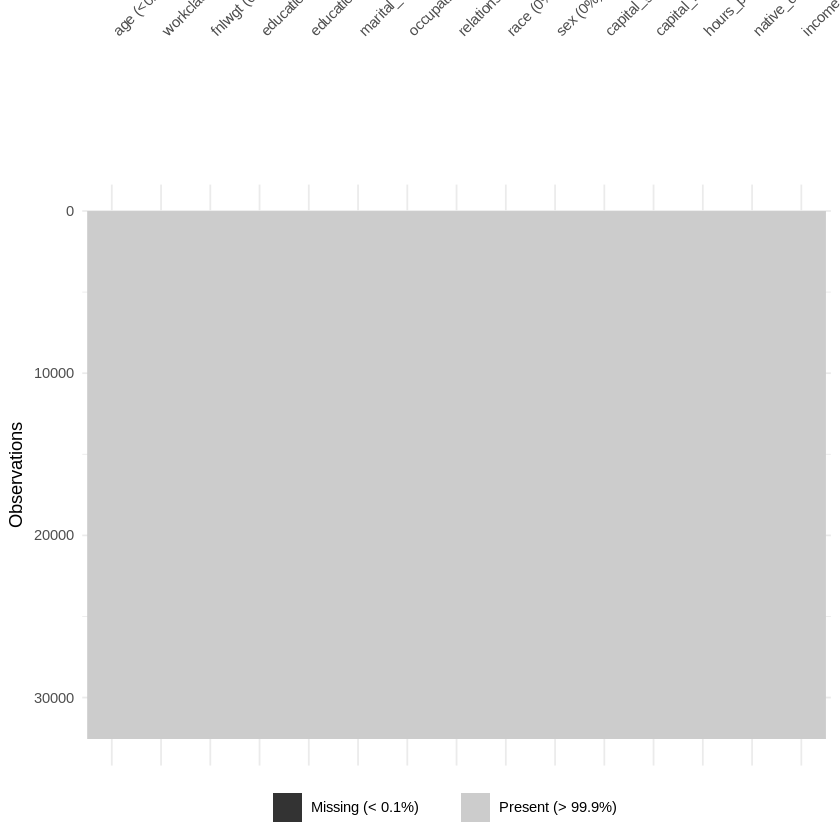

In [42]:
vis_miss(adult_test)

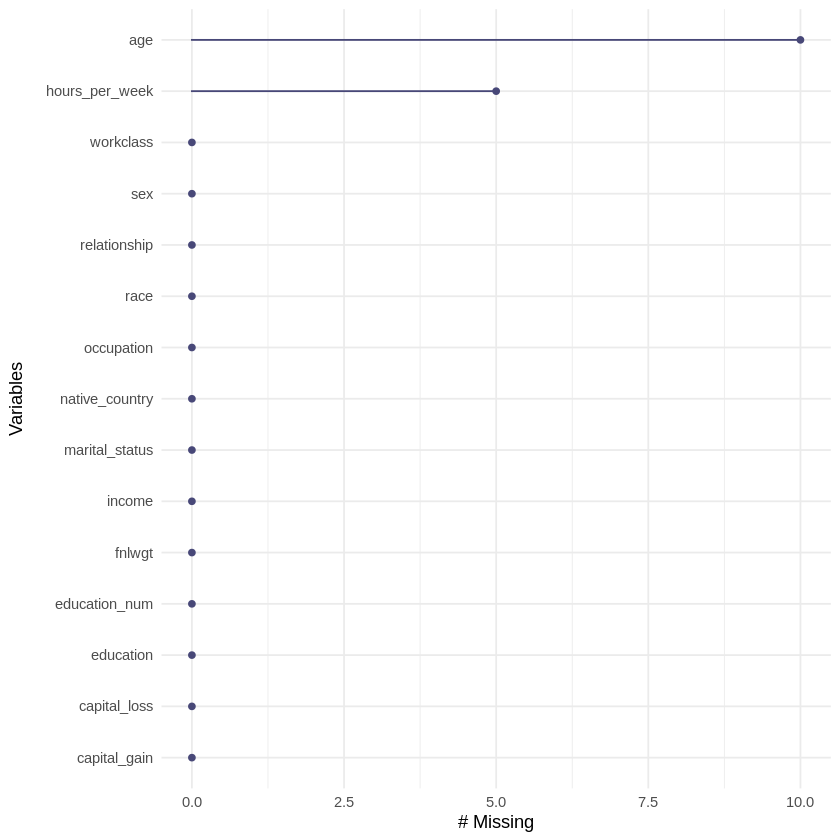

In [43]:
gg_miss_var(adult_test)

In [44]:
adult_clean <- adult_test

In [45]:
adult_clean$age[
  adult_clean$age == 999
] <- NA

cat(
  "Age = 999 values remaining:",
  sum(
    adult_clean$age == 999,
    na.rm = TRUE
  ),
  "\n"
)

Age = 999 values remaining: 0 


In [46]:
character_columns <- sapply(
  adult_clean,
  is.character
)

for (col in names(adult_clean)[character_columns]) {

  adult_clean[[col]][
    adult_clean[[col]] == ""
  ] <- "Unknown"
}

cat("Blank categorical values replaced.\n")

Blank categorical values replaced.


In [47]:
median_impute <- function(x) {

  # Check whether input is numeric
  if (!is.numeric(x)) {
    stop("Input must be numeric.")
  }

  # Get valid values
  valid_values <- x[
    !is.na(x) &
    !is.nan(x)
  ]

  # Check whether valid values exist
  if (length(valid_values) == 0) {
    stop("No valid values available.")
  }

  # Calculate median
  median_value <- median(
    valid_values
  )

  # Replace NA and NaN
  x[
    is.na(x) |
    is.nan(x)
  ] <- median_value

  return(x)
}

In [48]:
test_vector <- c(
  10,
  20,
  NA,
  30,
  NaN,
  40
)

cat("Original vector:\n")
print(test_vector)

cat("\nAfter median imputation:\n")
print(
  median_impute(test_vector)
)

Original vector:
[1]  10  20  NA  30 NaN  40

After median imputation:
[1] 10 20 25 30 25 40


In [49]:
numeric_columns <- sapply(
  adult_clean,
  is.numeric
)

for (col in names(adult_clean)[numeric_columns]) {

  adult_clean[[col]] <-
    median_impute(
      adult_clean[[col]]
    )
}

cat("Numeric missing values imputed.\n")

Numeric missing values imputed.


In [50]:
complete_rows <- complete.cases(
  adult_clean
)

cat(
  "Complete rows:",
  sum(complete_rows),
  "\n"
)

cat(
  "Incomplete rows:",
  sum(!complete_rows),
  "\n"
)

Complete rows: 32561 
Incomplete rows: 0 


In [51]:
adult_clean <- adult_clean[
  complete.cases(adult_clean),
]

cat(
  "Rows after removing remaining incomplete observations:",
  nrow(adult_clean),
  "\n"
)

Rows after removing remaining incomplete observations: 32561 


In [52]:
before_missing <- sapply(
  adult_test,
  function(x) sum(is.na(x))
)

before_missing

age      workclass         fnlwgt      education  education_num 
            10              0              0              0              0 
marital_status     occupation   relationship           race            sex 
             0              0              0              0              0 
  capital_gain   capital_loss hours_per_week native_country         income 
             0              0              5              0              0

In [53]:
after_missing <- sapply(
  adult_clean,
  function(x) sum(is.na(x))
)

after_missing

age      workclass         fnlwgt      education  education_num 
             0              0              0              0              0 
marital_status     occupation   relationship           race            sex 
             0              0              0              0              0 
  capital_gain   capital_loss hours_per_week native_country         income 
             0              0              0              0              0

In [54]:
missing_comparison <- data.frame(
  Variable = names(before_missing),
  Before = as.numeric(before_missing),
  After = as.numeric(after_missing)
)

print(missing_comparison)

         Variable Before After
1             age     10     0
2       workclass      0     0
3          fnlwgt      0     0
4       education      0     0
5   education_num      0     0
6  marital_status      0     0
7      occupation      0     0
8    relationship      0     0
9            race      0     0
10            sex      0     0
11   capital_gain      0     0
12   capital_loss      0     0
13 hours_per_week      5     0
14 native_country      0     0
15         income      0     0


In [55]:
before_percentage <- sapply(
  adult_test,
  function(x) {
    mean(is.na(x)) * 100
  }
)

print(before_percentage)

           age      workclass         fnlwgt      education  education_num 
    0.03071159     0.00000000     0.00000000     0.00000000     0.00000000 
marital_status     occupation   relationship           race            sex 
    0.00000000     0.00000000     0.00000000     0.00000000     0.00000000 
  capital_gain   capital_loss hours_per_week native_country         income 
    0.00000000     0.00000000     0.01535579     0.00000000     0.00000000 


In [56]:
after_percentage <- sapply(
  adult_clean,
  function(x) {
    mean(is.na(x)) * 100
  }
)

print(after_percentage)

           age      workclass         fnlwgt      education  education_num 
             0              0              0              0              0 
marital_status     occupation   relationship           race            sex 
             0              0              0              0              0 
  capital_gain   capital_loss hours_per_week native_country         income 
             0              0              0              0              0 


In [57]:
percentage_comparison <- data.frame(
  Variable = names(before_percentage),
  Before_Percent = as.numeric(
    before_percentage
  ),
  After_Percent = as.numeric(
    after_percentage
  )
)

print(percentage_comparison)

         Variable Before_Percent After_Percent
1             age     0.03071159             0
2       workclass     0.00000000             0
3          fnlwgt     0.00000000             0
4       education     0.00000000             0
5   education_num     0.00000000             0
6  marital_status     0.00000000             0
7      occupation     0.00000000             0
8    relationship     0.00000000             0
9            race     0.00000000             0
10            sex     0.00000000             0
11   capital_gain     0.00000000             0
12   capital_loss     0.00000000             0
13 hours_per_week     0.01535579             0
14 native_country     0.00000000             0
15         income     0.00000000             0


In [58]:
skim(adult_clean)

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,workclass,0,1,2,17,0,10,0,NA,NA,NA,NA,NA,NA,NA,NA
2,character,education,0,1,4,13,0,16,0,NA,NA,NA,NA,NA,NA,NA,NA
3,character,marital_status,0,1,8,22,0,7,0,NA,NA,NA,NA,NA,NA,NA,NA
4,character,occupation,0,1,2,18,0,15,0,NA,NA,NA,NA,NA,NA,NA,NA
5,character,relationship,0,1,5,15,0,6,0,NA,NA,NA,NA,NA,NA,NA,NA
6,character,race,0,1,6,19,0,5,0,NA,NA,NA,NA,NA,NA,NA,NA
7,character,sex,0,1,5,7,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA
8,character,native_country,0,1,2,27,0,42,0,NA,NA,NA,NA,NA,NA,NA,NA
9,character,income,0,1,5,6,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA


In [59]:
remaining_invalid_age <- sum(
  adult_clean$age == 999,
  na.rm = TRUE
)

cat(
  "Age = 999 values remaining:",
  remaining_invalid_age,
  "\n"
)

Age = 999 values remaining: 0 


In [60]:
remaining_blanks <- sapply(
  adult_clean,
  function(x) {

    if (is.character(x)) {
      sum(
        x == "",
        na.rm = TRUE
      )
    } else {
      0
    }
  }
)

print(remaining_blanks)

           age      workclass         fnlwgt      education  education_num 
             0              0              0              0              0 
marital_status     occupation   relationship           race            sex 
             0              0              0              0              0 
  capital_gain   capital_loss hours_per_week native_country         income 
             0              0              0              0              0 


In [61]:
numeric_missing <- sapply(
  adult_clean,
  function(x) {

    if (is.numeric(x)) {
      sum(
        is.na(x) |
        is.nan(x)
      )
    } else {
      0
    }
  }
)

print(numeric_missing)

           age      workclass         fnlwgt      education  education_num 
             0              0              0              0              0 
marital_status     occupation   relationship           race            sex 
             0              0              0              0              0 
  capital_gain   capital_loss hours_per_week native_country         income 
             0              0              0              0              0 


In [62]:
cat("Final Adult Dataset\n")
cat("====================\n")

cat(
  "Rows:",
  nrow(adult_clean),
  "\n"
)

cat(
  "Columns:",
  ncol(adult_clean),
  "\n"
)

cat(
  "Total missing values:",
  sum(is.na(adult_clean)),
  "\n"
)

Final Adult Dataset
Rows: 32561 
Columns: 15 
Total missing values: 0 


In [63]:
write.csv(
  adult_clean,
  "cleaned_adult_data.csv",
  row.names = FALSE
)

cat(
  "cleaned_adult_data.csv saved successfully.\n"
)

cleaned_adult_data.csv saved successfully.


In [64]:
cat("Assignment output files:\n")
cat("=========================\n")

cat(
  "1. cleaned_heart_data.csv\n"
)

cat(
  "2. cleaned_adult_data.csv\n"
)

cat("\nBoth datasets are ready for download from the Colab Files panel.\n")

Assignment output files:
1. cleaned_heart_data.csv
2. cleaned_adult_data.csv

Both datasets are ready for download from the Colab Files panel.
